In [1]:
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\baw61\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


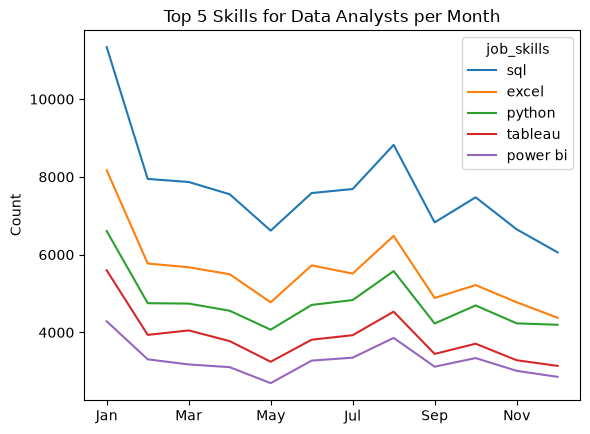

In [2]:
df_DA = df[df['job_title_short'] == 'Data Analyst'].copy()
# create a new column for month number
df_DA['job_posted_month_no'] = df_DA['job_posted_date'].dt.month

# Explode the job_skills column and pivot
df_DA_explode= df_DA.explode('job_skills')
df_DA_pivot = df_DA_explode.pivot_table(index='job_posted_month_no', columns='job_skills',  aggfunc='size', fill_value=0)

# sort the skills by count
df_DA_pivot.loc['Total'] = df_DA_pivot.sum()
df_DA_pivot = df_DA_pivot[df_DA_pivot.loc['Total'].sort_values(ascending=False).index]
df_DA_pivot = df_DA_pivot.drop('Total')

# Use month names for plotting
df_DA_pivot = df_DA_pivot.reset_index()
df_DA_pivot['job_posted_month'] = df_DA_pivot['job_posted_month_no'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
df_DA_pivot = df_DA_pivot.set_index('job_posted_month')
df_DA_pivot = df_DA_pivot.drop(columns='job_posted_month_no')

# Get the top 5 skills
df_DA_pivot.iloc[:, :5].plot(kind='line')

plt.title('Top 5 Skills for Data Analysts per Month')
plt.ylabel('Count')
plt.xlabel('')
plt.show()

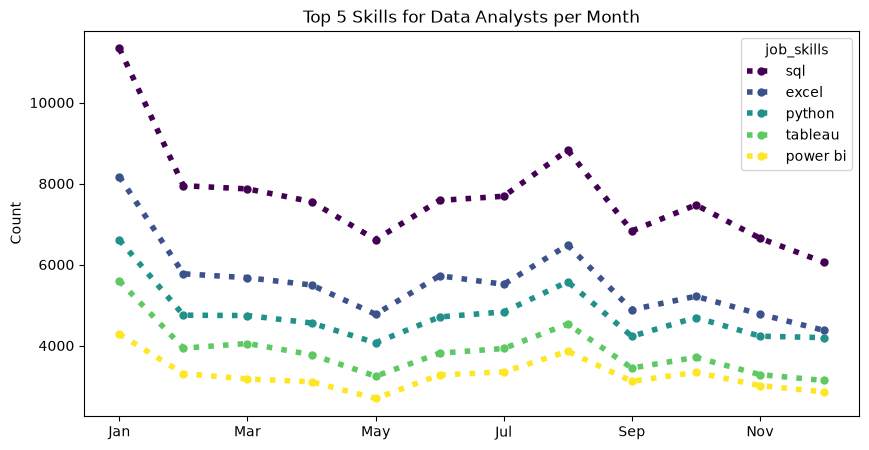

In [11]:
df_DA_pivot.iloc[:, :5].plot(
    kind='line',
    linewidth=4,
    linestyle=':', #options: '-', '--', '-.', ':'
    colormap='viridis',
    marker='o',
    markersize=5,
    figsize=(10,5)
    )

plt.title('Top 5 Skills for Data Analysts per Month')
plt.ylabel('Count')
plt.xlabel('')
plt.show()

In [12]:
# Explode the 'job_skills' into individual rows
df_exploded = df_DA.explode('job_skills')

# Calculate the average salary and count of job postings per skill
skill_stats = df_exploded.groupby('job_skills').agg(
    median_salary=('salary_year_avg', 'median'),
    skill_count=('job_skills', 'count')
)

# Limit to the top skills
skill_count = 20
skill_stats = skill_stats.sort_values(by='skill_count', ascending=False).head(skill_count)

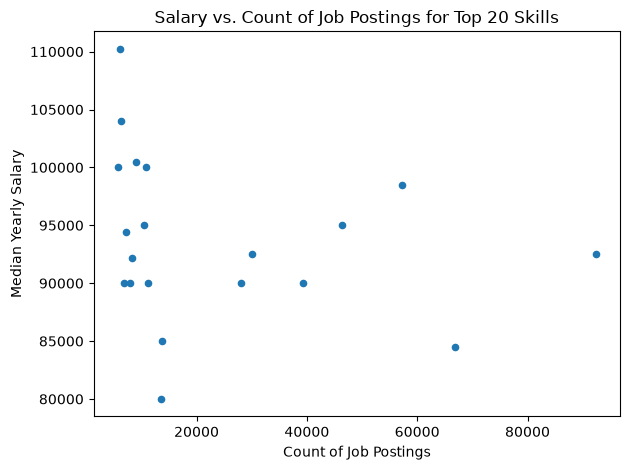

In [13]:
skill_stats.plot(kind='scatter', x='skill_count', y='median_salary')
plt.xlabel('Count of Job Postings')
plt.ylabel('Median Yearly Salary')
plt.title(f'Salary vs. Count of Job Postings for Top {skill_count} Skills')
plt.tight_layout()
plt.show()

In [17]:
%pip install adjustText

  Using cached adjusttext-1.4.0-py3-none-any.whl.metadata (3.4 kB)
Using cached adjusttext-1.4.0-py3-none-any.whl (13 kB)
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   ---- ----------------------------------- 4.2/36.6 MB 22.9 MB/s eta 0:00:02
   ---------- ----------------------------- 10.0/36.6 MB 24.8 MB/s eta 0:00:02
   ---------------- ----------------------- 15.2/36.6 MB 24.5 MB/s eta 0:00:01
   ---------------------- ----------------- 20.4/36.6 MB 24.4 MB/s eta 0:00:01
   ---------------------------- ----------- 26.0/36.6 MB 24.9 MB/s eta 0:00:01
   ---------------------------------- ----- 31.5/36.6 MB 25.0 MB/s eta 0:00:01
   ---------------------------------------  36.2/36.6 MB 24.4 MB/s eta 0:00:01
   ---------------------------------------- 36.6/36.6 MB 22.4 MB/s  0:00:01

   ---------------------------------------- 0/2 [scipy]
   ---------------------------------------- 0/2 [scipy]
   ---------------------------------------- 0/2 [scipy]
   --------

In [18]:
from adjustText import adjust_text

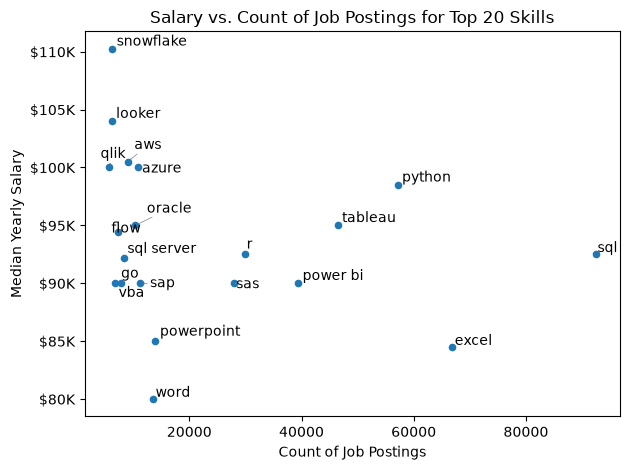

In [29]:
#fig, ax = plt.subplots()

skill_stats.plot(kind='scatter', x='skill_count', y='median_salary')

texts = []
for i, txt in enumerate(skill_stats.index):
    texts.append(plt.text(skill_stats['skill_count'].iloc[i], skill_stats['median_salary'].iloc[i], txt))

adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=0.5))

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))

plt.xlabel('Count of Job Postings')
plt.ylabel('Median Yearly Salary')
plt.title(f'Salary vs. Count of Job Postings for Top {skill_count} Skills')
plt.tight_layout()
plt.show()

In [57]:
df_ce = df[df['job_title_short'] == 'Cloud Engineer']
df_ce['job_month'] = df_ce['job_posted_date'].dt.month
job_count = df_ce['job_month'].value_counts().sort_index()


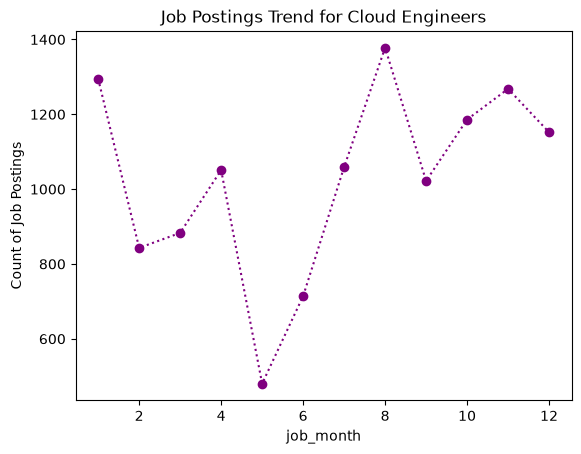

In [58]:
job_count.plot(kind='line', x='job_count', y= 'job_month', linestyle=':', color='purple', marker='o')
plt.title('Job Postings Trend for Cloud Engineers')
plt.ylabel('Count of Job Postings')
plt.show()

In [ ]:
df

In [ ]:
SDA_df = df[df['job_title_short'] == 'Senior Data Analyst']
top_companies = SDA_df['company_name'].value_counts().head(5)
colors = ['blue', 'orange', 'green', 'red', 'purple']

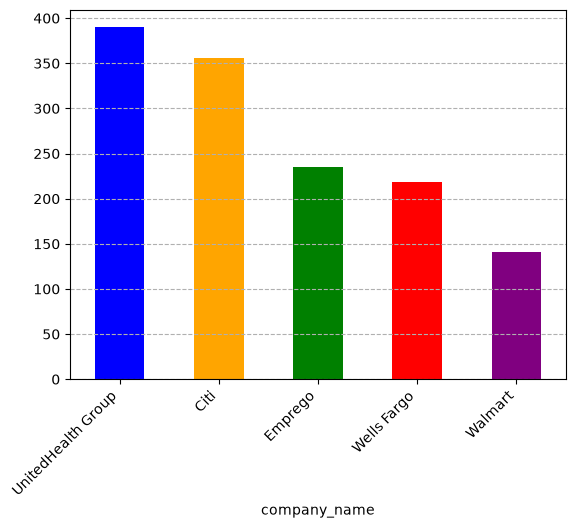

In [70]:
top_companies.plot(kind= 'bar', color= colors)
plt.grid(axis= 'y', linestyle='--')
plt.xticks(rotation=45, ha='right')
plt.show()